In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigs

In [2]:
# --- Constantes físicas ---
hbar = 1.054e-34  # J·s
m = 9.11e-31      # kg
eV = 1.602e-19    # J

# --- Quantidade de estados calculados ---
num_estados = 6

# --- Parâmetros do poço ---
L = 5e-9          # Largura do poço
V0 = 0.35 * eV    # Altura das barreiras

# --- Parâmetros computacionais ---
N = 1000                     # Pontos da malha
x = np.linspace(-L, 2*L, N)  # eixo x expandido para mostrar além do poço
dx = x[1] - x[0]

# --- Potencial ---
V = np.zeros(N)
V[x <= 0] = V0      # barreira esquerda
V[x >= L] = V0      # barreira direita

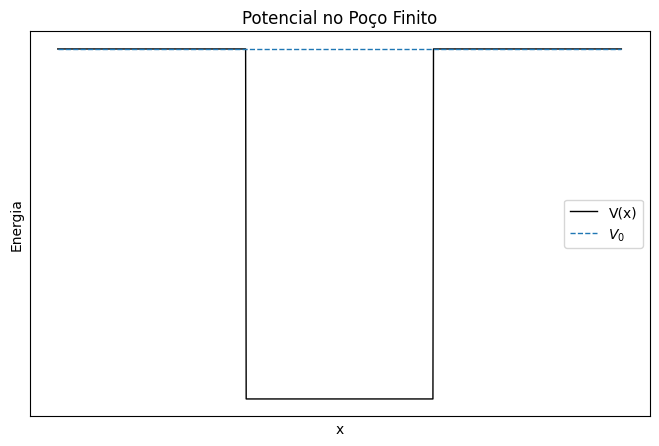

In [3]:
# ------------------- PLOT: Potencial -------------------
plt.figure(figsize=(8, 5))

# Potencial do poço
plt.plot(x*1e9, V/eV, 'k-', linewidth=1, label='V(x)')
plt.plot(x*1e9, [V0/eV]*len(x), linestyle='--', linewidth=1, label='$V_0$')

plt.xlabel('x')
plt.ylabel('Energia')
plt.title('Potencial no Poço Finito')
plt.legend(loc='center right')

# Omitindo valores nos eixos
plt.xticks([])   # remove números do eixo x
plt.yticks([])   # remove números do eixo y

# Salvar figura 
plt.savefig("potencial_poco.png", dpi=300, bbox_inches='tight')

plt.show()

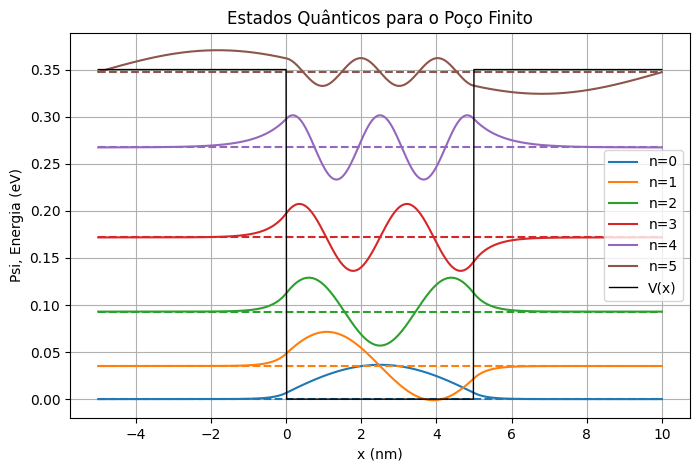

n = 0  ->  E = 0.000 eV
n = 1  ->  E = 0.035 eV
n = 2  ->  E = 0.093 eV
n = 3  ->  E = 0.172 eV
n = 4  ->  E = 0.267 eV
n = 5  ->  E = 0.347 eV


In [4]:
# --- Hamiltoniano (diferenças finitas) ---
main_diag = (hbar**2 / (m * dx**2)) + V
off_diag = -hbar**2 / (2*m*dx**2) * np.ones(N-1)
H = diags([main_diag, off_diag, off_diag], [0, -1, 1])

# --- Autovalores e autovetores ---
E, psi = eigs(H, k=num_estados, which='SR')
E = np.real(E)
psi = np.real(psi)

# Ordenar e ajustar zero
idx = np.argsort(E)
E = E[idx]
psi = psi[:, idx]
E = E - np.min(E)

# ------------------- PLOT: Estados com linhas de energia e barreiras -------------------
plt.figure(figsize=(8, 5))
for n in range(num_estados):
    # Mantém referencial padronizado (todas as ondas 'para cima')
    if np.max(psi[:, n]) < np.abs(np.min(psi[:, n])):
        psi[:, n] *= -1
    # Linha horizontal representando energia
    plt.hlines(E[n]/eV, x[0]*1e9, x[-1]*1e9, colors='C'+str(n), linestyles='--')
    # Função de onda deslocada verticalmente para visualização
    plt.plot(x*1e9, psi[:, n]*0.5 + E[n]/eV, label=f'n={n}')

# Potencial do poço
plt.plot(x*1e9, V/eV, 'k-', linewidth=1, label='V(x)')

plt.xlabel('x (nm)')
plt.ylabel('Psi, Energia (eV)')
plt.title('Estados Quânticos para o Poço Finito')
plt.legend(loc='center right')
plt.grid(True)
# Salvar figura 
plt.savefig("estados_poco.png", dpi=300, bbox_inches='tight')
plt.show()

# ------------------- Mostrar energias -------------------
for n, En in enumerate(E):
    print(f"n = {n}  ->  E = {En/eV:.3f} eV")
